# EDA: ROI-First GGO / Lung Opacity Pipeline

This notebook matches the current `pipeline.py` and `main.py` implementation.
It is designed to answer the next practical questions:

1. How much GT is captured by the strict lung mask vs the broader analysis mask?
2. What HU ranges do RexGroundCT targets occupy inside those masks?
3. Which detector settings are stable across multiple cases instead of only one case?
4. Are failures caused by ROI exclusion or lesion-threshold failure?


2d mask channels used: 899
Skipped: 182


,split,case_name,channel,category,finding_text,ct_path,mask_path,n_voxels,hu_min,hu_p1,hu_p5,hu_p25,hu_p50,hu_p75,hu_p95,hu_p99,hu_max,hu_mean,hu_median,hu_std
0,train,train_1741_c_2.nii.gz,1,2d,Subcentimeter nonspecific nodules in both lungs,/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...,462,-883.0,-877.00,-852.95,-789.75,-728.0,-581.75,-213.10,-78.44,-36.0,-658.073593,-728.0,191.485102
1,train,train_1624_a_1.nii.gz,2,2d,Multiple subcentimeter nonspecific nodules in ...,/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...,798,-916.0,-883.09,-838.15,-737.75,-653.5,-524.00,-285.85,-185.22,-46.0,-618.030075,-653.5,165.535053
2,train,train_1591_c_2.nii.gz,5,2d,Subcentimeter nonspecific parenchymal nodules ...,/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...,4746,-871.0,-848.00,-809.00,-259.00,95.0,229.00,423.00,522.55,624.0,-41.952592,95.0,394.941855
3,train,train_2282_a_2.nii.gz,1,2d,Subcentimeter nonspecific parenchymal nodules ...,/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...,319,-933.0,-926.82,-899.10,-766.50,-602.0,-320.00,-59.60,6.86,35.0,-540.492163,-602.0,266.042704
4,train,train_1959_b_2.nii.gz,6,2d,Well-defined cavitary nodules measuring 8 mm i...,/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...,2903,-937.0,-859.96,-760.00,-712.00,-650.0,-492.00,-191.20,-101.02,-9.0,-583.005856,-650.0,178.193802


Saved: /home/chest_ct/code/data/rexgrounding-ct/all_2d_hu_stats.csv

Global pooled HU distribution inside all 2d GT masks
Number of voxels: 6280546
Min : -1152.0
P1  : -980.0
P5  : -816.0
P25 : -39.0
P50 : 19.0
P75 : 44.0
P95 : 79.0
P99 : 114.0
Max : 3071.0
Mean: -104.77832261717373
Median: 19.0
Std : 290.2822266672097


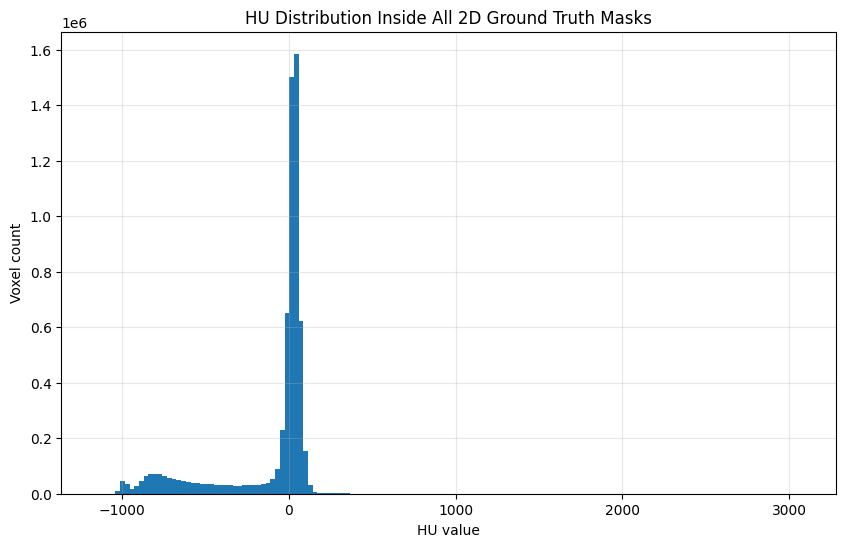

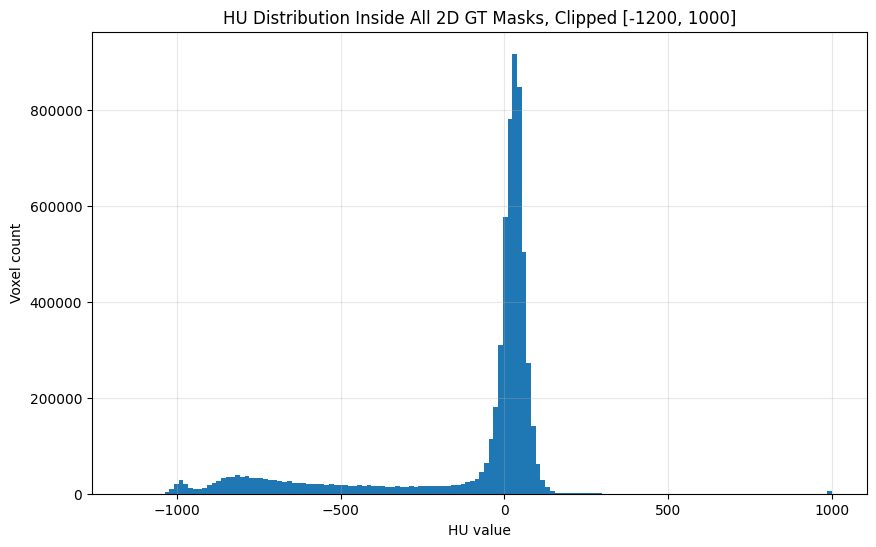


First 20 skipped:
('train', 'train_10588_a_2.nii.gz', 'missing CT')
('train', 'train_12643_a_1.nii.gz', 'missing CT')
('train', 'train_11262_a_1.nii.gz', 'missing CT')
('train', 'train_11068_a_1.nii.gz', 'missing CT')
('train', 'train_10888_b_2.nii.gz', 'missing CT')
('train', 'train_10624_b_1.nii.gz', 'missing CT')
('train', 'train_11245_a_1.nii.gz', 'missing CT')
('train', 'train_11054_a_2.nii.gz', 'missing CT')
('train', 'train_11094_a_1.nii.gz', 'missing CT')
('train', 'train_10903_a_2.nii.gz', 'missing CT')
('train', 'train_12821_a_1.nii.gz', 'missing CT')
('train', 'train_12228_a_2.nii.gz', 'missing CT')
('train', 'train_11520_a_2.nii.gz', 'missing CT')
('train', 'train_10577_a_2.nii.gz', 'missing CT')
('train', 'train_11904_a_2.nii.gz', 'missing CT')
('train', 'train_11008_a_2.nii.gz', 'missing CT')
('train', 'train_11164_b_2.nii.gz', 'missing CT')
('train', 'train_12383_a_1.nii.gz', 'missing CT')
('train', 'train_12050_b_1.nii.gz', 'missing CT')
('train', 'train_10259_a_2.nii.

In [8]:
import json
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Paths
# -----------------------------
dataset_json = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_4.json")

ct_root = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed")
seg_root = Path("/home/chest_ct/code/data/segmentations/segmentations")

out_csv = Path("/home/chest_ct/code/data/rexgrounding-ct/all_2d_hu_stats.csv")


# -----------------------------
# Helpers
# -----------------------------
def resolve_ct_path(case_name):
    case_id = case_name.replace(".nii.gz", "")
    parts = case_id.split("_")

    patient_dir = "_".join(parts[:2])   # train_1696
    series_dir = "_".join(parts[:-1])   # train_1696_a

    return ct_root / patient_dir / series_dir / case_name


def resolve_seg_path(case_name):
    return seg_root / case_name


def hu_stats(values):
    return {
        "n_voxels": int(values.size),
        "hu_min": float(np.min(values)),
        "hu_p1": float(np.percentile(values, 1)),
        "hu_p5": float(np.percentile(values, 5)),
        "hu_p25": float(np.percentile(values, 25)),
        "hu_p50": float(np.percentile(values, 50)),
        "hu_p75": float(np.percentile(values, 75)),
        "hu_p95": float(np.percentile(values, 95)),
        "hu_p99": float(np.percentile(values, 99)),
        "hu_max": float(np.max(values)),
        "hu_mean": float(np.mean(values)),
        "hu_median": float(np.median(values)),
        "hu_std": float(np.std(values)),
    }


# -----------------------------
# Load dataset_4
# -----------------------------
data = json.loads(dataset_json.read_text())

rows = []
all_hu_values = []
skipped = []


# -----------------------------
# Loop over all 2d cases
# -----------------------------
for split, items in data.items():
    if not isinstance(items, list):
        continue

    for item in items:
        case_name = item["name"]
        categories = item.get("categories", {})
        findings = item.get("findings", {})

        # Get all channels where category == 2d
        channels_2d = [
            int(ch)
            for ch, cat in categories.items()
            if str(cat).lower() == "2d"
        ]

        if not channels_2d:
            continue

        volume_path = resolve_ct_path(case_name)
        mask_path = resolve_seg_path(case_name)

        if not volume_path.exists():
            skipped.append((split, case_name, "missing CT"))
            continue

        if not mask_path.exists():
            skipped.append((split, case_name, "missing mask"))
            continue

        # Same as your one-case code
        ct = nib.load(str(volume_path)).get_fdata()
        gt_mask = nib.load(str(mask_path)).get_fdata()

        if gt_mask.ndim == 3:
            gt_mask = gt_mask[np.newaxis, ...]

        if ct.shape != gt_mask.shape[1:]:
            skipped.append((split, case_name, f"shape mismatch CT={ct.shape}, mask={gt_mask.shape}"))
            continue

        # Process each 2d channel separately
        for finding in channels_2d:
            if finding >= gt_mask.shape[0]:
                skipped.append((split, case_name, f"channel {finding} out of range"))
                continue

            gt_mask_single = gt_mask[finding]
            gt_bool = gt_mask_single > 0

            gt_hu_values = ct[gt_bool]
            gt_hu_values = gt_hu_values[np.isfinite(gt_hu_values)]

            if gt_hu_values.size == 0:
                skipped.append((split, case_name, f"empty mask channel {finding}"))
                continue

            stats = hu_stats(gt_hu_values)

            rows.append({
                "split": split,
                "case_name": case_name,
                "channel": finding,
                "category": categories.get(str(finding)),
                "finding_text": findings.get(str(finding)),
                "ct_path": str(volume_path),
                "mask_path": str(mask_path),
                **stats,
            })

            all_hu_values.append(gt_hu_values)


# -----------------------------
# Results
# -----------------------------
stats_df = pd.DataFrame(rows)

print("2d mask channels used:", len(stats_df))
print("Skipped:", len(skipped))

display(stats_df.head())

stats_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)


# -----------------------------
# Global pooled HU distribution
# -----------------------------
if all_hu_values:
    all_hu_values = np.concatenate(all_hu_values)

    print("\nGlobal pooled HU distribution inside all 2d GT masks")
    print("Number of voxels:", all_hu_values.size)
    print("Min :", float(np.min(all_hu_values)))
    print("P1  :", float(np.percentile(all_hu_values, 1)))
    print("P5  :", float(np.percentile(all_hu_values, 5)))
    print("P25 :", float(np.percentile(all_hu_values, 25)))
    print("P50 :", float(np.percentile(all_hu_values, 50)))
    print("P75 :", float(np.percentile(all_hu_values, 75)))
    print("P95 :", float(np.percentile(all_hu_values, 95)))
    print("P99 :", float(np.percentile(all_hu_values, 99)))
    print("Max :", float(np.max(all_hu_values)))
    print("Mean:", float(np.mean(all_hu_values)))
    print("Median:", float(np.median(all_hu_values)))
    print("Std :", float(np.std(all_hu_values)))

    plt.figure(figsize=(10, 6))
    plt.hist(all_hu_values, bins=150)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside All 2D Ground Truth Masks")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(np.clip(all_hu_values, -1200, 1000), bins=150)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside All 2D GT Masks, Clipped [-1200, 1000]")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No HU values found.")


# -----------------------------
# Optional: inspect skipped cases
# -----------------------------
if skipped:
    print("\nFirst 20 skipped:")
    for row in skipped[:20]:
        print(row)

Found 875 cases with category 2d in dataset_4.json
Aggregate HU stats for GT lung nodule category 2D voxels


,value
n_dataset_4_2d_cases,8.750000e+02
n_cases_used,6.930000e+02
n_cases_skipped,1.820000e+02
total_gt_2d_voxels,5.039494e+06
hu_min,-1.152000e+03
hu_q01,-9.870000e+02
hu_q05,-8.390000e+02
hu_q25,-1.230000e+02
hu_mean,-1.327877e+02
hu_std,3.118547e+02



Per-case stats, largest masks first


,split,name,channels,n_2d_channels,n_voxels,hu_min,hu_q01,hu_q05,hu_q25,hu_mean,hu_std,hu_median,hu_q75,hu_q95,hu_q99,hu_max,findings,categories,ct_path,seg_path
574,train,train_122_b_1.nii.gz,[0],1,1098312,-1092.0,-796.000000,-269.0,5.0,-5.352730,155.382690,26.0,45.00,73.000000,104.000000,1602.0,{'0': 'Stable mass in the upper lobe of the ri...,"{'0': '2d', '1': '2c'}",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
597,train,train_340_a_1.nii.gz,"[0, 1, 2, 3, 4]",5,1021342,-1024.0,-524.589844,-51.0,0.0,16.625204,94.627960,27.0,54.00,93.000000,122.000000,1089.0,{'0': 'Mass in the left upper lobe and lingula...,"{'0': '2d', '1': '2d', '2': '2d', '3': '2d', '...",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
590,train,train_122_c_1.nii.gz,"[0, 3]",2,827338,-1086.0,-861.000000,-751.0,-15.0,-86.153404,260.653046,23.0,45.00,75.000000,97.000000,1157.0,{'0': 'Unchanged mass with necrotic content in...,"{'0': '2d', '1': '2c', '2': '2b', '3': '2d'}",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
672,train,train_1157_e_2.nii.gz,"[0, 1, 2, 3, 4, 5]",6,288803,-1024.0,-996.000000,-975.0,-641.0,-304.682312,354.892303,-151.0,18.00,43.000000,54.000000,959.0,{'0': 'Bilateral pulmonary lesions consistent ...,"{'0': '2d', '1': '2d', '2': '2d', '3': '2d', '...",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
269,train,train_6970_b_2.nii.gz,"[0, 2, 3, 4]",4,270105,-1024.0,-1020.000000,-1004.0,-234.0,-191.514175,371.156158,8.0,28.00,52.000000,69.000000,198.0,{'0': 'Thick-walled cavitary mass measuring 6....,"{'0': '2d', '1': '2c', '2': '2d', '3': '2d', '...",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
594,train,train_119_a_2.nii.gz,"[0, 1, 2, 3]",4,187049,-1024.0,-1002.000000,-983.0,-744.0,-324.902039,405.521515,-85.0,32.00,66.000000,96.000000,3071.0,{'0': 'Centrally located mass in the right upp...,"{'0': '2d', '1': '2d', '2': '2d', '3': '2d'}",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
627,train,train_412_c_2.nii.gz,"[0, 1]",2,181417,-932.0,-330.000000,1.0,30.0,33.824268,69.761955,43.0,55.00,74.000000,88.000000,170.0,{'0': 'Infiltrative mass in the left pulmonary...,"{'0': '2d', '1': '2d', '2': '2b', '3': '2c', '...",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
372,train,train_6970_a_2.nii.gz,"[0, 2, 3, 4]",4,171264,-1024.0,-998.000000,-956.0,-255.0,-161.588211,311.212372,8.0,31.00,54.000000,68.000000,114.0,{'0': 'Thick-walled cavitary mass measuring ap...,"{'0': '2d', '1': '2c', '2': '2d', '3': '2d', '...",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
329,train,train_7641_b_2.nii.gz,"[0, 1]",2,148015,-1024.0,-738.000000,-342.0,15.0,-8.909732,148.012711,31.0,45.00,65.000000,81.000000,137.0,{'0': 'Cystic-necrotic mass in the posterior s...,"{'0': '2d', '1': '2d'}",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...
74,train,train_1409_a_2.nii.gz,"[0, 3, 4, 5]",4,74712,-939.0,-829.000000,-296.0,8.0,-14.106088,149.482285,26.0,39.00,58.000000,72.000000,198.0,{'0': '45 mm mass lesion in the lower lobe of ...,"{'0': '2d', '1': '2a', '2': '2b', '3': '2d', '...",/home/chest_ct/code/data/data_volumes/dataset/...,/home/chest_ct/code/data/segmentations/segment...



Saved per-case stats to: /home/chest_ct/code/data/rexgrounding-ct/lung_nodule_2d_hu_stats_from_dataset_4.csv

Skipped 182 cases. First 30:
('train', 'train_10588_a_2.nii.gz', 'missing CT')
('train', 'train_12643_a_1.nii.gz', 'missing CT')
('train', 'train_11262_a_1.nii.gz', 'missing CT')
('train', 'train_11068_a_1.nii.gz', 'missing CT')
('train', 'train_10888_b_2.nii.gz', 'missing CT')
('train', 'train_10624_b_1.nii.gz', 'missing CT')
('train', 'train_11245_a_1.nii.gz', 'missing CT')
('train', 'train_11054_a_2.nii.gz', 'missing CT')
('train', 'train_11094_a_1.nii.gz', 'missing CT')
('train', 'train_10903_a_2.nii.gz', 'missing CT')
('train', 'train_12821_a_1.nii.gz', 'missing CT')
('train', 'train_12228_a_2.nii.gz', 'missing CT')
('train', 'train_11520_a_2.nii.gz', 'missing CT')
('train', 'train_10577_a_2.nii.gz', 'missing CT')
('train', 'train_11904_a_2.nii.gz', 'missing CT')
('train', 'train_11008_a_2.nii.gz', 'missing CT')
('train', 'train_11164_b_2.nii.gz', 'missing CT')
('train', 

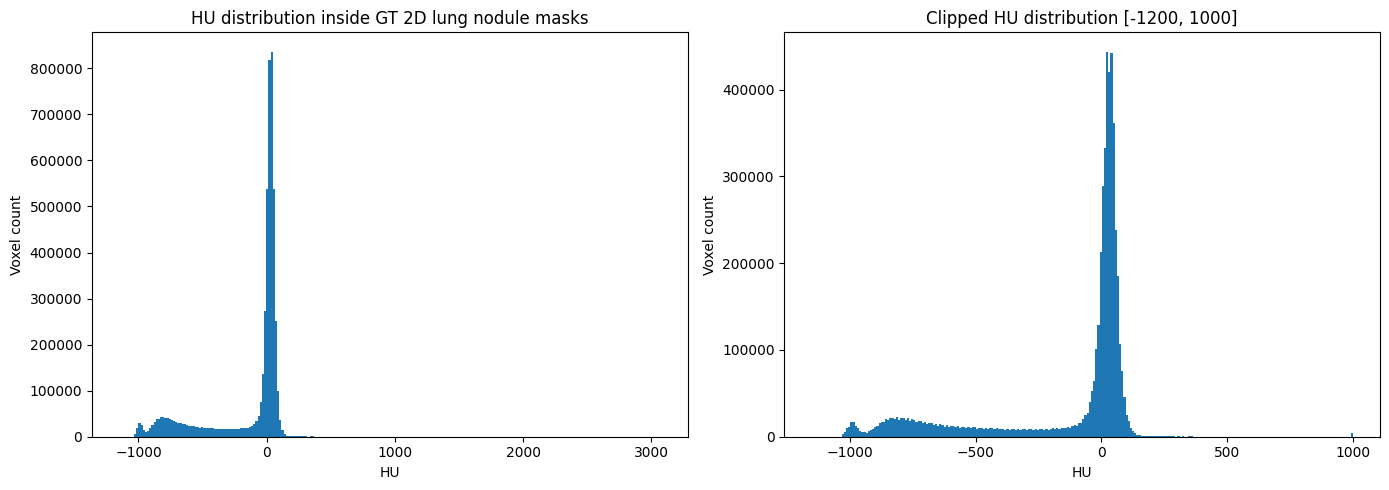

/tmp/ipykernel_1844088/1343901595.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


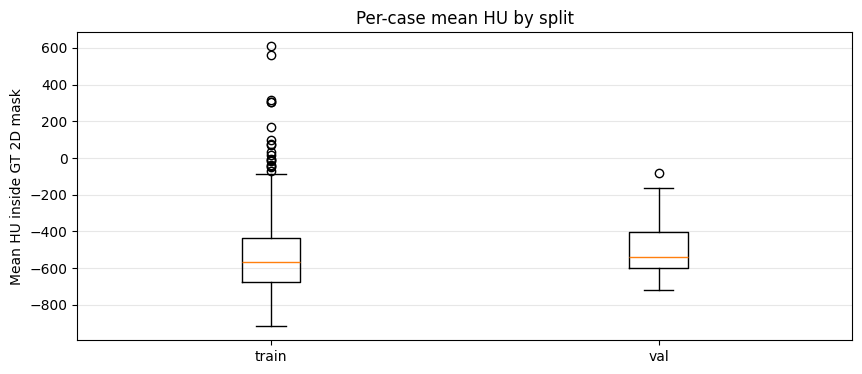

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt


DATASET_JSON = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_4.json")

CT_ROOT  = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed")
SEG_ROOT = Path("/home/chest_ct/code/data/segmentations/segmentations")

OUT_CSV = Path("/home/chest_ct/code/data/rexgrounding-ct/lung_nodule_2d_hu_stats_from_dataset_4.csv")


def resolve_ct_path(name: str) -> Path:
    case_id = name.replace(".nii.gz", "")
    parts = case_id.split("_")
    patient_dir = "_".join(parts[:2])
    series_dir = "_".join(parts[:-1])
    return CT_ROOT / patient_dir / series_dir / name


def resolve_seg_path(name: str) -> Path:
    return SEG_ROOT / name


def get_category_channels(item: dict, target_category: str = "2d") -> list[int]:
    return sorted(
        int(ch)
        for ch, cat in item.get("categories", {}).items()
        if str(cat).lower() == target_category.lower()
    )


def make_binary_mask(seg_path: Path, channels: list[int]) -> np.ndarray:
    seg_img = nib.load(str(seg_path))
    seg = seg_img.get_fdata(dtype=np.float32)

    if seg.ndim == 3:
        seg = seg[np.newaxis, ...]

    mask = np.zeros(seg.shape[1:], dtype=bool)

    for ch in channels:
        if ch >= seg.shape[0]:
            print(f"[WARN] {seg_path.name}: channel {ch} out of range, seg has {seg.shape[0]} channels")
            continue
        mask |= seg[ch] > 0

    return mask


data = json.loads(DATASET_JSON.read_text())

cases = []
for split, items in data.items():
    if not isinstance(items, list):
        continue

    for item in items:
        channels = get_category_channels(item, "2d")
        if channels:
            cases.append((split, item, channels))

print(f"Found {len(cases)} cases with category 2d in {DATASET_JSON.name}")


all_hu_values = []
case_rows = []
skipped = []

for split, item, channels in cases:
    name = item["name"]

    ct_path = resolve_ct_path(name)
    seg_path = resolve_seg_path(name)

    if not ct_path.exists():
        skipped.append((split, name, "missing CT"))
        continue

    if not seg_path.exists():
        skipped.append((split, name, "missing segmentation"))
        continue

    ct_img = nib.load(str(ct_path))
    ct = ct_img.get_fdata(dtype=np.float32)

    mask = make_binary_mask(seg_path, channels)

    if ct.shape != mask.shape:
        skipped.append((split, name, f"shape mismatch CT={ct.shape}, mask={mask.shape}"))
        continue

    hu = ct[mask]
    hu = hu[np.isfinite(hu)]

    if hu.size == 0:
        skipped.append((split, name, "empty 2d mask"))
        continue

    all_hu_values.append(hu)

    case_rows.append({
        "split": split,
        "name": name,
        "channels": channels,
        "n_2d_channels": len(channels),
        "n_voxels": int(hu.size),
        "hu_min": float(np.min(hu)),
        "hu_q01": float(np.percentile(hu, 1)),
        "hu_q05": float(np.percentile(hu, 5)),
        "hu_q25": float(np.percentile(hu, 25)),
        "hu_mean": float(np.mean(hu)),
        "hu_std": float(np.std(hu)),
        "hu_median": float(np.median(hu)),
        "hu_q75": float(np.percentile(hu, 75)),
        "hu_q95": float(np.percentile(hu, 95)),
        "hu_q99": float(np.percentile(hu, 99)),
        "hu_max": float(np.max(hu)),
        "findings": item.get("findings", {}),
        "categories": item.get("categories", {}),
        "ct_path": str(ct_path),
        "seg_path": str(seg_path),
    })


case_stats = pd.DataFrame(case_rows)

if not all_hu_values:
    raise RuntimeError("No HU values extracted. Check CT/seg paths and local data availability.")

all_hu = np.concatenate(all_hu_values)

summary = {
    "n_dataset_4_2d_cases": len(cases),
    "n_cases_used": len(case_stats),
    "n_cases_skipped": len(skipped),
    "total_gt_2d_voxels": int(all_hu.size),
    "hu_min": float(np.min(all_hu)),
    "hu_q01": float(np.percentile(all_hu, 1)),
    "hu_q05": float(np.percentile(all_hu, 5)),
    "hu_q25": float(np.percentile(all_hu, 25)),
    "hu_mean": float(np.mean(all_hu)),
    "hu_std": float(np.std(all_hu)),
    "hu_median": float(np.median(all_hu)),
    "hu_q75": float(np.percentile(all_hu, 75)),
    "hu_q95": float(np.percentile(all_hu, 95)),
    "hu_q99": float(np.percentile(all_hu, 99)),
    "hu_max": float(np.max(all_hu)),
}

print("Aggregate HU stats for GT lung nodule category 2D voxels")
display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

print("\nPer-case stats, largest masks first")
display(case_stats.sort_values("n_voxels", ascending=False).head(30))

case_stats.to_csv(OUT_CSV, index=False)
print(f"\nSaved per-case stats to: {OUT_CSV}")

if skipped:
    print(f"\nSkipped {len(skipped)} cases. First 30:")
    for row in skipped[:30]:
        print(row)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_hu, bins=250)
axes[0].set_title("HU distribution inside GT 2D lung nodule masks")
axes[0].set_xlabel("HU")
axes[0].set_ylabel("Voxel count")

clip_min, clip_max = -1200, 1000
axes[1].hist(np.clip(all_hu, clip_min, clip_max), bins=250)
axes[1].set_title(f"Clipped HU distribution [{clip_min}, {clip_max}]")
axes[1].set_xlabel("HU")
axes[1].set_ylabel("Voxel count")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.boxplot(
    [case_stats.loc[case_stats["split"] == split, "hu_mean"] for split in case_stats["split"].unique()],
    labels=list(case_stats["split"].unique()),
    showfliers=True,
)
plt.title("Per-case mean HU by split")
plt.ylabel("Mean HU inside GT 2D mask")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [5]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

PROJECT_DIR = Path(r"D:\\My\\Projects\\fyp-3d-ct\\image-processing")
DATASET_JSON = Path(r"D:\\My\\Projects\\fyp-3d-ct\\data\\rexgrounding-ct\\dataset_img_processing.json")

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from pipeline import (
    load_nifti_file,
    load_ggo_gt_mask,
    get_voxel_spacing,
    apply_hu_window,
    get_lung_mask,
    get_analysis_mask,
    detect_ggo,
    detect_lung_opacity,
    min_volume_to_voxels,
    spacing_to_sigma_voxels,
    get_case_adaptive_threshold,
    compute_dice,
    compute_iou,
    compute_sensitivity_precision,
)

print("Imports complete")

ImportError: cannot import name 'get_analysis_mask' from 'pipeline' (/home/chest_ct/code/image-processing/pipeline.py)

In [3]:
with open(DATASET_JSON, "r", encoding="utf-8") as f:
    dataset = json.load(f)

SPLIT = "train"
CASE_INDEX = 0
samples = dataset[SPLIT]
sample = samples[CASE_INDEX]

print("Total samples in split:", len(samples))
print("Selected case:", sample["name"])
print("CT path:", sample["ct_path"])
print("SEG path:", sample["seg_path"])
print("GGO channels:", sample["ggo_channels"])
print("Findings:")
for ch in sample["ggo_channels"]:
    print(f"  Channel {ch}: {sample['findings'][str(ch)]}")

Total samples in split: 18
Selected case: train_67_a_2.nii.gz
CT path: D:\My\Projects\fyp-3d-ct\data\data_volumes\train_67\train_67_a\train_67_a_2.nii.gz
SEG path: D:\My\Projects\fyp-3d-ct\data\segmentations\train_67_a_2.nii.gz
GGO channels: [0]
Findings:
  Channel 0: Peripherally located patchy ground glass opacities in bilateral lungs with associated vascular enlargement


In [4]:
ct_data, ct_affine, ct_header = load_nifti_file(sample["ct_path"])
gt_mask, gt_affine, gt_header = load_ggo_gt_mask(sample["seg_path"], sample["ggo_channels"])
spacing = get_voxel_spacing(ct_header)

print("CT shape:", ct_data.shape)
print("GT shape:", gt_mask.shape)
print("Spacing:", spacing)
print("GT voxels:", int(gt_mask.sum()))

CT shape: (512, 512, 496)
GT shape: (512, 512, 496)
Spacing: (0.71484375, 0.71484375, 0.75)
GT voxels: 23131


In [5]:
LUNG_THRESHOLD = -400
ANALYSIS_UPPER_HU = 100
ANALYSIS_DILATION_ITERATIONS = 2
ANALYSIS_CLOSING_ITERATIONS = 2

lung_mask = get_lung_mask(ct_data, lung_threshold=LUNG_THRESHOLD)
analysis_mask = get_analysis_mask(
    ct_data,
    lung_threshold=LUNG_THRESHOLD,
    upper_hu=ANALYSIS_UPPER_HU,
    dilation_iterations=ANALYSIS_DILATION_ITERATIONS,
    closing_iterations=ANALYSIS_CLOSING_ITERATIONS,
)

gt_inside_lung = float((gt_mask & lung_mask).sum() / (gt_mask.sum() + 1e-8))
gt_inside_analysis = float((gt_mask & analysis_mask).sum() / (gt_mask.sum() + 1e-8))

print("Lung voxels:", int(lung_mask.sum()))
print("Analysis voxels:", int(analysis_mask.sum()))
print("GT inside lung mask ratio:", round(gt_inside_lung, 4))
print("GT inside analysis mask ratio:", round(gt_inside_analysis, 4))

Lung voxels: 5705682
Analysis voxels: 6515258
GT inside lung mask ratio: 0.4881
GT inside analysis mask ratio: 0.9561


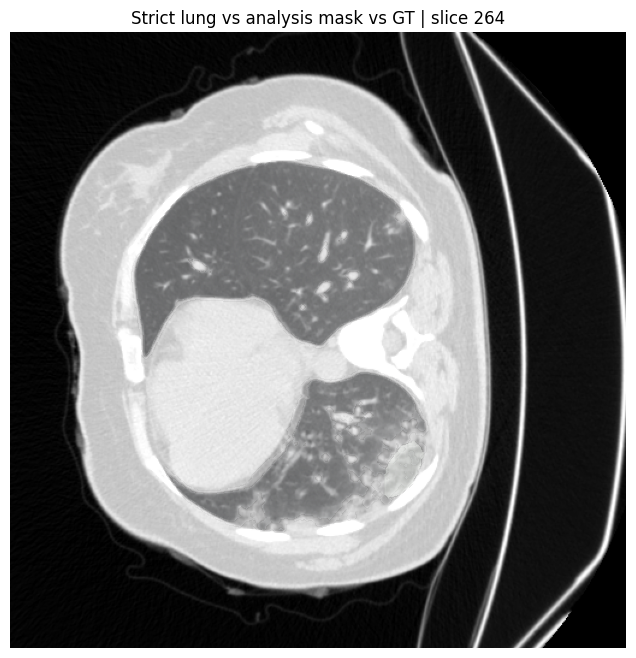

In [6]:
def get_gt_slices(mask):
    return np.where(mask.sum(axis=(0, 1)) > 0)[0]


def show_overlay(ct, gt=None, pred=None, lung=None, analysis=None, slice_idx=None, title=""):
    if slice_idx is None:
        if gt is not None and gt.sum() > 0:
            slices = get_gt_slices(gt)
            slice_idx = int(slices[len(slices) // 2])
        else:
            slice_idx = ct.shape[2] // 2

    ct_windowed = apply_hu_window(ct)
    plt.figure(figsize=(8, 8))
    plt.imshow(ct_windowed[:, :, slice_idx], cmap="gray")
    if analysis is not None:
        plt.imshow(np.ma.masked_where(~analysis[:, :, slice_idx], analysis[:, :, slice_idx]), alpha=0.18, cmap="Purples")
    if lung is not None:
        plt.imshow(np.ma.masked_where(~lung[:, :, slice_idx], lung[:, :, slice_idx]), alpha=0.18, cmap="Blues")
    if gt is not None:
        plt.imshow(np.ma.masked_where(~gt[:, :, slice_idx], gt[:, :, slice_idx]), alpha=0.35, cmap="Greens")
    if pred is not None:
        plt.imshow(np.ma.masked_where(~pred[:, :, slice_idx], pred[:, :, slice_idx]), alpha=0.35, cmap="Reds")
    plt.title(f"{title} | slice {slice_idx}")
    plt.axis("off")
    plt.show()


show_overlay(
    ct_data,
    gt=gt_mask,
    lung=lung_mask,
    analysis=analysis_mask,
    title="Strict lung vs analysis mask vs GT",
)

In [7]:
def print_hu_stats(values, label):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        print(label, "is empty")
        return

    print(f"\n{label} HU statistics")
    print("Min :", float(np.min(values)))
    print("P1  :", float(np.percentile(values, 1)))
    print("P5  :", float(np.percentile(values, 5)))
    print("P25 :", float(np.percentile(values, 25)))
    print("P50 :", float(np.percentile(values, 50)))
    print("P75 :", float(np.percentile(values, 75)))
    print("P95 :", float(np.percentile(values, 95)))
    print("P99 :", float(np.percentile(values, 99)))
    print("Max :", float(np.max(values)))
    print("Mean:", float(np.mean(values)))
    print("Std :", float(np.std(values)))


lung_values = ct_data[lung_mask]
analysis_values = ct_data[analysis_mask]
gt_values = ct_data[gt_mask]

print_hu_stats(gt_values, "GT target")
print_hu_stats(lung_values, "Strict lung mask")
print_hu_stats(analysis_values, "Analysis mask")


GT target HU statistics
Min : -802.0
P1  : -745.0
P5  : -675.0
P25 : -521.0
P50 : -387.0
P75 : -259.0
P95 : -109.0
P99 : -42.0
Max : 201.0
Mean: -390.4189147949219
Std : 173.6312255859375

Strict lung mask HU statistics
Min : -1024.0
P1  : -864.0
P5  : -841.0
P25 : -801.0
P50 : -757.0
P75 : -694.0
P95 : -492.0
P99 : -355.0
Max : 45.0
Mean: -728.1524047851562
Std : 108.42618560791016

Analysis mask HU statistics
Min : -1024.0
P1  : -863.0
P5  : -838.0
P25 : -795.0
P50 : -742.0
P75 : -630.0
P95 : -113.0
P99 : 6.0
Max : 440.0
Mean: -658.0072021484375
Std : 216.8124237060547


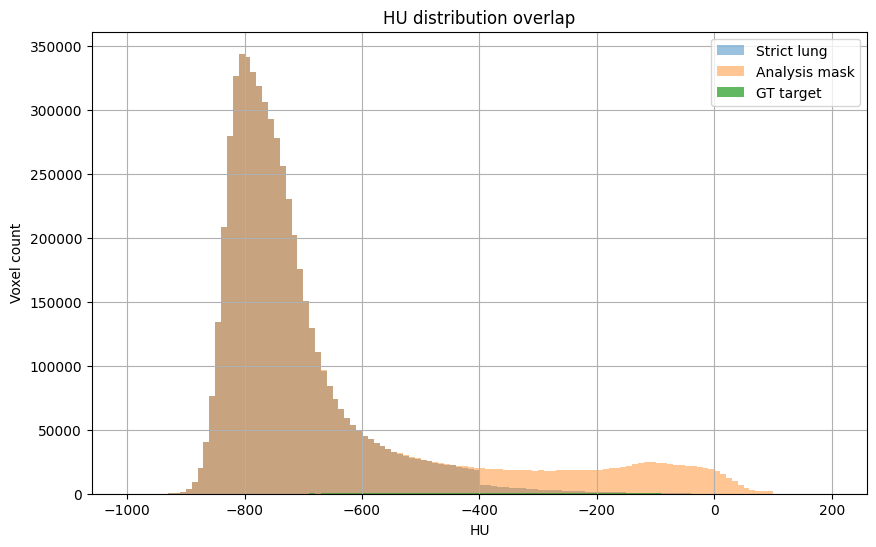

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(lung_values, bins=120, range=(-1000, 200), alpha=0.45, label="Strict lung")
plt.hist(analysis_values, bins=120, range=(-1000, 200), alpha=0.45, label="Analysis mask")
plt.hist(gt_values, bins=120, range=(-1000, 200), alpha=0.75, label="GT target")
plt.xlabel("HU")
plt.ylabel("Voxel count")
plt.title("HU distribution overlap")
plt.legend()
plt.grid(True)
plt.show()

## Single-Case Detector Sweep

This section is still useful, but it should only be used to generate candidate settings.
The real decision should be based on the multi-case section below.

In [9]:
DETECTION_MODE = "ggo"

parameter_sets = []
for percentile in [88, 90, 92, 95]:
    for sigma in [1.0, 1.5, 2.0]:
        for min_volume in [100, 300, 500]:
            parameter_sets.append({
                "lower_hu": -750,
                "upper_hu": -250,
                "percentile": percentile,
                "sigma_mm": sigma,
                "min_volume_mm3": min_volume,
            })

results = []
for params in parameter_sets:
    min_vox = min_volume_to_voxels(params["min_volume_mm3"], spacing=spacing)
    pred = detect_ggo(
        ct_data,
        analysis_mask,
        spacing=spacing,
        lower_hu=params["lower_hu"],
        upper_hu=params["upper_hu"],
        min_size=min_vox,
        smoothing_sigma_mm=params["sigma_mm"],
        adaptive_percentile=params["percentile"],
    )
    dice = compute_dice(pred, gt_mask)
    iou = compute_iou(pred, gt_mask)
    sensitivity, precision = compute_sensitivity_precision(pred, gt_mask)
    results.append({
        **params,
        "min_voxels": min_vox,
        "dice": float(dice),
        "iou": float(iou),
        "sensitivity": float(sensitivity),
        "precision": float(precision),
        "pred_voxels": int(pred.sum()),
    })

single_case_df = pd.DataFrame(results).sort_values(["dice", "precision"], ascending=False)
display(single_case_df.head(12))

,lower_hu,upper_hu,percentile,sigma_mm,min_volume_mm3,min_voxels,dice,iou,sensitivity,precision,pred_voxels
17,-750,-250,90,2.0,500,1305,0.268277,0.154919,0.203536,0.393415,11967
16,-750,-250,90,2.0,300,783,0.260672,0.149869,0.203536,0.362405,12991
1,-750,-250,88,1.0,300,783,0.235061,0.133183,0.202369,0.280350,16697
2,-750,-250,88,1.0,500,1305,0.235061,0.133183,0.202369,0.280350,16697
5,-750,-250,88,1.5,500,1305,0.232617,0.131616,0.280360,0.198768,32626
15,-750,-250,90,2.0,100,261,0.231809,0.131100,0.204185,0.268078,17618
0,-750,-250,88,1.0,100,261,0.222059,0.124897,0.203018,0.245043,19164
4,-750,-250,88,1.5,300,783,0.215109,0.120517,0.280360,0.174497,37164
3,-750,-250,88,1.5,100,261,0.193296,0.106988,0.280360,0.147494,43968
12,-750,-250,90,1.5,100,261,0.193011,0.106813,0.126670,0.405256,7230


Best single-case setting:
{'lower_hu': -750.0, 'upper_hu': -250.0, 'percentile': 90.0, 'sigma_mm': 2.0, 'min_volume_mm3': 500.0, 'min_voxels': 1305.0, 'dice': 0.26827739472334605, 'iou': 0.15491938137545244, 'sensitivity': 0.2035363797500309, 'precision': 0.3934152252023118, 'pred_voxels': 11967.0}


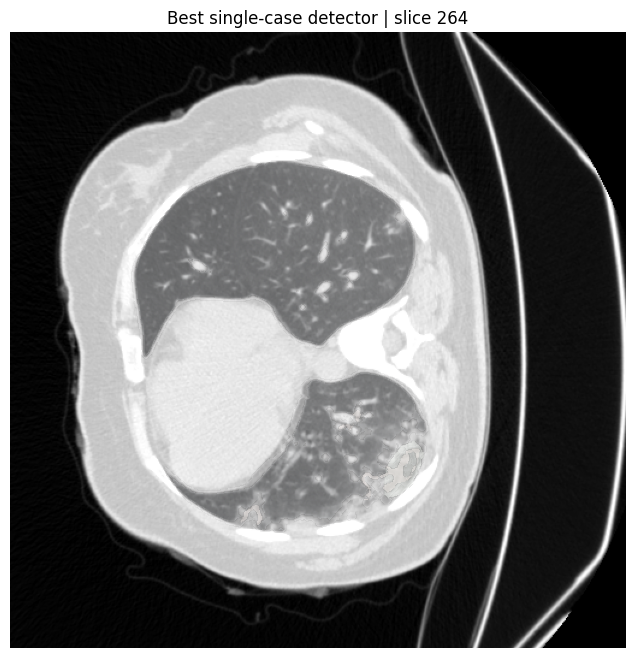

In [10]:
best = single_case_df.iloc[0].to_dict()
best_min_vox = min_volume_to_voxels(best["min_volume_mm3"], spacing=spacing)

best_pred = detect_ggo(
    ct_data,
    analysis_mask,
    spacing=spacing,
    lower_hu=best["lower_hu"],
    upper_hu=best["upper_hu"],
    min_size=best_min_vox,
    smoothing_sigma_mm=best["sigma_mm"],
    adaptive_percentile=best["percentile"],
)

print("Best single-case setting:")
print(best)
show_overlay(ct_data, gt=gt_mask, pred=best_pred, lung=lung_mask, analysis=analysis_mask, title="Best single-case detector")

## Multi-Case Evaluation

This section is the main decision-maker.
It tracks not only overlap metrics but also whether the ROI stage excluded the GT before lesion detection even started.

In [11]:
def run_detector(ct, analysis, spacing, params, mode="ggo"):
    min_vox = min_volume_to_voxels(params["min_volume_mm3"], spacing=spacing)
    if mode == "ggo":
        pred = detect_ggo(
            ct,
            analysis,
            spacing=spacing,
            lower_hu=params["lower_hu"],
            upper_hu=params["upper_hu"],
            min_size=min_vox,
            smoothing_sigma_mm=params["sigma_mm"],
            adaptive_percentile=params["percentile"],
        )
    elif mode == "opacity":
        pred = detect_lung_opacity(
            ct,
            analysis,
            spacing=spacing,
            lower_hu=params["lower_hu"],
            upper_hu=params["upper_hu"],
            min_size=min_vox,
            smoothing_sigma_mm=params["sigma_mm"],
            adaptive_percentile=params["percentile"],
        )
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    return pred, min_vox


def evaluate_sample(sample, params, mode="ggo"):
    ct, _, header = load_nifti_file(sample["ct_path"])
    gt, _, _ = load_ggo_gt_mask(sample["seg_path"], sample["ggo_channels"])
    spacing = get_voxel_spacing(header)
    lung = get_lung_mask(ct, lung_threshold=LUNG_THRESHOLD)
    analysis = get_analysis_mask(
        ct,
        lung_threshold=LUNG_THRESHOLD,
        upper_hu=ANALYSIS_UPPER_HU,
        dilation_iterations=ANALYSIS_DILATION_ITERATIONS,
        closing_iterations=ANALYSIS_CLOSING_ITERATIONS,
    )
    pred, min_vox = run_detector(ct, analysis, spacing, params, mode=mode)
    dice = compute_dice(pred, gt)
    iou = compute_iou(pred, gt)
    sensitivity, precision = compute_sensitivity_precision(pred, gt)
    gt_inside_lung = float((gt & lung).sum() / (gt.sum() + 1e-8))
    gt_inside_analysis = float((gt & analysis).sum() / (gt.sum() + 1e-8))
    zero_prediction = int(pred.sum() == 0)
    roi_failure = int(gt_inside_analysis < 0.8)
    return {
        "name": sample["name"],
        "dice": float(dice),
        "iou": float(iou),
        "sensitivity": float(sensitivity),
        "precision": float(precision),
        "gt_voxels": int(gt.sum()),
        "pred_voxels": int(pred.sum()),
        "lung_voxels": int(lung.sum()),
        "analysis_voxels": int(analysis.sum()),
        "gt_inside_lung": gt_inside_lung,
        "gt_inside_analysis": gt_inside_analysis,
        "zero_prediction": zero_prediction,
        "roi_failure": roi_failure,
        "min_voxels": int(min_vox),
    }


def evaluate_many(samples_subset, param_grid, mode="ggo"):
    summary_rows = []
    all_case_rows = []
    for params in param_grid:
        case_rows = []
        for sample in samples_subset:
            case_rows.append(evaluate_sample(sample, params, mode=mode))
        case_df = pd.DataFrame(case_rows)
        all_case_rows.append(case_df.assign(**params, mode=mode))
        summary_rows.append({
            **params,
            "mode": mode,
            "mean_dice": float(case_df["dice"].mean()),
            "mean_iou": float(case_df["iou"].mean()),
            "mean_sensitivity": float(case_df["sensitivity"].mean()),
            "mean_precision": float(case_df["precision"].mean()),
            "mean_gt_inside_lung": float(case_df["gt_inside_lung"].mean()),
            "mean_gt_inside_analysis": float(case_df["gt_inside_analysis"].mean()),
            "zero_prediction_cases": int(case_df["zero_prediction"].sum()),
            "roi_failure_cases": int(case_df["roi_failure"].sum()),
        })
    return pd.DataFrame(summary_rows).sort_values(["mean_dice", "mean_precision"], ascending=False), pd.concat(all_case_rows, ignore_index=True)

In [12]:
if "samples_subset" not in globals():
    if "samples" not in globals():
        if "dataset" not in globals():
            with open(DATASET_JSON, "r", encoding="utf-8") as f:
                dataset = json.load(f)
        samples = dataset[SPLIT]
    EVAL_CASES = min(5, len(samples))
    samples_subset = samples[:EVAL_CASES]

print("Evaluating", len(samples_subset), "cases from split", SPLIT)


ggo_grid = [
    {"lower_hu": -750, "upper_hu": -250, "percentile": 88, "sigma_mm": 1.0, "min_volume_mm3": 300},
    {"lower_hu": -750, "upper_hu": -250, "percentile": 90, "sigma_mm": 1.0, "min_volume_mm3": 500},
    {"lower_hu": -750, "upper_hu": -250, "percentile": 90, "sigma_mm": 1.5, "min_volume_mm3": 500},
    {"lower_hu": -700, "upper_hu": -250, "percentile": 92, "sigma_mm": 1.5, "min_volume_mm3": 500},
]

opacity_grid = [
    {"lower_hu": -700, "upper_hu": 50, "percentile": 95, "sigma_mm": 1.5, "min_volume_mm3": 300},
    {"lower_hu": -700, "upper_hu": 100, "percentile": 95, "sigma_mm": 2.0, "min_volume_mm3": 500},
]

ggo_summary, ggo_cases = evaluate_many(samples_subset, ggo_grid, mode="ggo")
display(ggo_summary)
display(ggo_cases.sort_values(["dice", "gt_inside_analysis"], ascending=[False, False]).head(20))

Evaluating 5 cases from split train


,lower_hu,upper_hu,percentile,sigma_mm,min_volume_mm3,mode,mean_dice,mean_iou,mean_sensitivity,mean_precision,mean_gt_inside_lung,mean_gt_inside_analysis,zero_prediction_cases,roi_failure_cases
0,-750,-250,88,1.0,300,ggo,0.047012,0.026637,0.040474,0.056070,0.538868,0.778427,2,1
2,-750,-250,90,1.5,500,ggo,0.038053,0.021027,0.023319,0.103353,0.538868,0.778427,3,1
1,-750,-250,90,1.0,500,ggo,0.000000,0.000000,0.000000,0.000000,0.538868,0.778427,5,1
3,-700,-250,92,1.5,500,ggo,0.000000,0.000000,0.000000,0.000000,0.538868,0.778427,5,1


,name,dice,iou,sensitivity,precision,gt_voxels,pred_voxels,lung_voxels,analysis_voxels,gt_inside_lung,gt_inside_analysis,zero_prediction,roi_failure,min_voxels,lower_hu,upper_hu,percentile,sigma_mm,min_volume_mm3,mode
0,train_67_a_2.nii.gz,0.235061,0.133183,0.202369,0.280350,23131,16697,5705682,6515258,0.488133,0.956076,0,0,783,-750,-250,88,1.0,300,ggo
10,train_67_a_2.nii.gz,0.190265,0.105134,0.116597,0.516766,23131,5219,5705682,6515258,0.488133,0.956076,0,0,1305,-750,-250,90,1.5,500,ggo
3,train_244_b_1.nii.gz,0.000000,0.000000,0.000000,0.000000,1514,1810,5362687,6306532,1.000000,1.000000,0,0,718,-750,-250,88,1.0,300,ggo
8,train_244_b_1.nii.gz,0.000000,0.000000,0.000000,0.000000,1514,0,5362687,6306532,1.000000,1.000000,1,0,1196,-750,-250,90,1.0,500,ggo
13,train_244_b_1.nii.gz,0.000000,0.000000,0.000000,0.000000,1514,0,5362687,6306532,1.000000,1.000000,1,0,1196,-750,-250,90,1.5,500,ggo
18,train_244_b_1.nii.gz,0.000000,0.000000,0.000000,0.000000,1514,0,5362687,6306532,1.000000,1.000000,1,0,1196,-700,-250,92,1.5,500,ggo
2,train_33_a_1.nii.gz,0.000000,0.000000,0.000000,0.000000,890062,0,4878440,6073370,0.642478,0.980947,1,0,584,-750,-250,88,1.0,300,ggo
7,train_33_a_1.nii.gz,0.000000,0.000000,0.000000,0.000000,890062,0,4878440,6073370,0.642478,0.980947,1,0,973,-750,-250,90,1.0,500,ggo
12,train_33_a_1.nii.gz,0.000000,0.000000,0.000000,0.000000,890062,0,4878440,6073370,0.642478,0.980947,1,0,973,-750,-250,90,1.5,500,ggo
17,train_33_a_1.nii.gz,0.000000,0.000000,0.000000,0.000000,890062,0,4878440,6073370,0.642478,0.980947,1,0,973,-700,-250,92,1.5,500,ggo


In [13]:
opacity_summary, opacity_cases = evaluate_many(samples_subset, opacity_grid, mode="opacity")
display(opacity_summary)
display(opacity_cases.sort_values(["dice", "gt_inside_analysis"], ascending=[False, False]).head(20))

,lower_hu,upper_hu,percentile,sigma_mm,min_volume_mm3,mode,mean_dice,mean_iou,mean_sensitivity,mean_precision,mean_gt_inside_lung,mean_gt_inside_analysis,zero_prediction_cases,roi_failure_cases
1,-700,100,95,2.0,500,opacity,0.015370,0.007811,0.022840,0.044501,0.538868,0.778427,1,1
0,-700,50,95,1.5,300,opacity,0.011028,0.005595,0.008771,0.100646,0.538868,0.778427,1,1


,name,dice,iou,sensitivity,precision,gt_voxels,pred_voxels,lung_voxels,analysis_voxels,gt_inside_lung,gt_inside_analysis,zero_prediction,roi_failure,min_voxels,lower_hu,upper_hu,percentile,sigma_mm,min_volume_mm3,mode
5,train_67_a_2.nii.gz,0.044091,0.022543,0.074575,0.031298,23131,55116,5705682,6515258,0.488133,0.956076,0,0,1305,-700,100,95,2.0,500,opacity
0,train_67_a_2.nii.gz,0.034061,0.017325,0.033073,0.035109,23131,21789,5705682,6515258,0.488133,0.956076,0,0,783,-700,50,95,1.5,300,opacity
2,train_33_a_1.nii.gz,0.021077,0.010651,0.010781,0.468120,890062,20499,4878440,6073370,0.642478,0.980947,0,0,584,-700,50,95,1.5,300,opacity
7,train_33_a_1.nii.gz,0.016918,0.008531,0.008875,0.180540,890062,43752,4878440,6073370,0.642478,0.980947,0,0,973,-700,100,95,2.0,500,opacity
9,train_298_a_2.nii.gz,0.015840,0.007983,0.030749,0.010668,35643,102737,17558436,21839657,0.563729,0.955110,0,0,1460,-700,100,95,2.0,500,opacity
3,train_244_b_1.nii.gz,0.000000,0.000000,0.000000,0.000000,1514,18116,5362687,6306532,1.000000,1.000000,0,0,718,-700,50,95,1.5,300,opacity
8,train_244_b_1.nii.gz,0.000000,0.000000,0.000000,0.000000,1514,45195,5362687,6306532,1.000000,1.000000,0,0,1196,-700,100,95,2.0,500,opacity
4,train_298_a_2.nii.gz,0.000000,0.000000,0.000000,0.000000,35643,27680,17558436,21839657,0.563729,0.955110,0,0,876,-700,50,95,1.5,300,opacity
1,train_20_a_2.nii.gz,0.000000,0.000000,0.000000,0.000000,293909,0,999313,2000793,0.000000,0.000000,1,1,639,-700,50,95,1.5,300,opacity
6,train_20_a_2.nii.gz,0.000000,0.000000,0.000000,0.000000,293909,0,999313,2000793,0.000000,0.000000,1,1,1065,-700,100,95,2.0,500,opacity


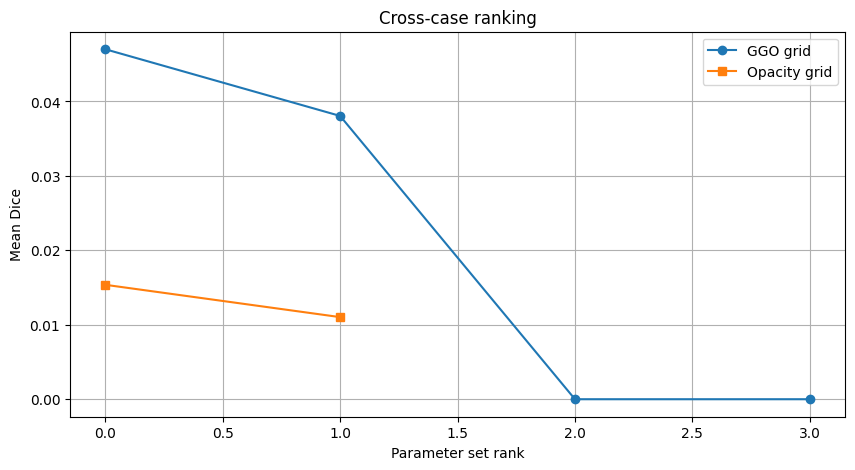

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(ggo_summary)), ggo_summary["mean_dice"].values, marker="o", label="GGO grid")
plt.plot(range(len(opacity_summary)), opacity_summary["mean_dice"].values, marker="s", label="Opacity grid")
plt.xlabel("Parameter set rank")
plt.ylabel("Mean Dice")
plt.title("Cross-case ranking")
plt.grid(True)
plt.legend()
plt.show()

## Recommended Decision Rules

Use the notebook outputs to decide the next implementation step:

- If `mean_gt_inside_analysis` is still low, improve the ROI stage before tuning thresholds again.
- If ROI coverage is high but `mean_precision` is poor, focus on false-positive suppression.
- If GGO settings fail but opacity settings improve strongly, treat this as a broader lung-opacity problem instead of pure GGO segmentation.
- Prefer the parameter set with fewer `zero_prediction_cases` and fewer `roi_failure_cases`, even if its single best-case Dice is slightly lower.
